Random_state:  10
              precision    recall  f1-score   support

     Aquacel       0.70      0.88      0.78         8
    Na Ultra       0.83      0.62      0.71         8

    accuracy                           0.75        16
   macro avg       0.77      0.75      0.75        16
weighted avg       0.77      0.75      0.75        16

Accuracy: 75.0 %
Random_state:  7
              precision    recall  f1-score   support

     Aquacel       0.78      0.88      0.82         8
    Na Ultra       0.86      0.75      0.80         8

    accuracy                           0.81        16
   macro avg       0.82      0.81      0.81        16
weighted avg       0.82      0.81      0.81        16

Accuracy: 81.25 %
Random_state:  37
              precision    recall  f1-score   support

     Aquacel       0.78      0.88      0.82         8
    Na Ultra       0.86      0.75      0.80         8

    accuracy                           0.81        16
   macro avg       0.82      0.81      0

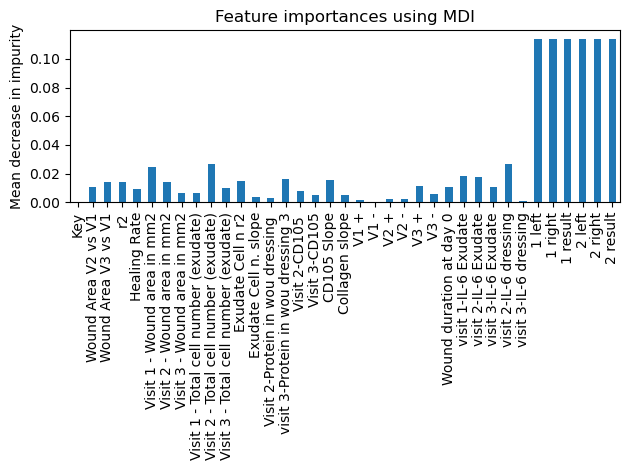

[[0.52507377 0.4749262 ]
 [0.52233815 0.47766182]
 [0.40648347 0.5935165 ]
 [0.6632356  0.3367644 ]
 [0.6657269  0.33427313]
 [0.6657921  0.33420786]
 [0.5386069  0.4613931 ]
 [0.6656129  0.33438712]
 [0.4937631  0.5062369 ]
 [0.46357232 0.5364277 ]
 [0.46168303 0.53831697]
 [0.49393505 0.50606495]
 [0.4915319  0.5084681 ]
 [0.5223212  0.47767875]
 [0.48854887 0.5114511 ]
 [0.6621688  0.3378312 ]]


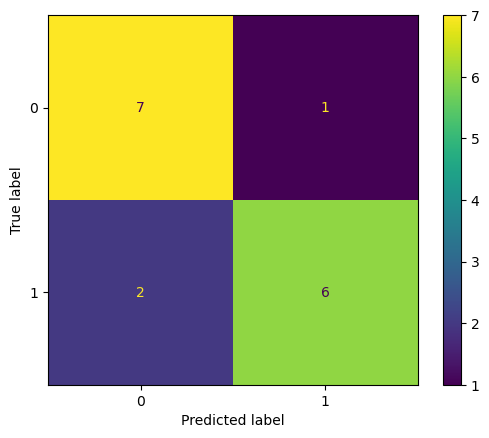

<Figure size 40000x12000 with 0 Axes>

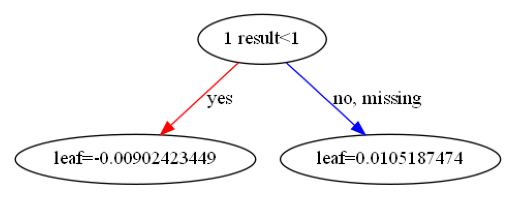

              precision    recall  f1-score   support

     Aquacel       1.00      1.00      1.00        17
    Na Ultra       1.00      1.00      1.00        14

    accuracy                           1.00        31
   macro avg       1.00      1.00      1.00        31
weighted avg       1.00      1.00      1.00        31

--------------------------------------------------------------------------------------------------


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import re
import random
from tensorflow.keras.utils import to_categorical
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
import xgboost as xgb
from xgboost import plot_tree
from xgboost import XGBClassifier
from dtreeviz import model
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import pickle




W_tree=0
Treatment=pd.read_csv("treatment_train.csv")
Treatment_test=pd.read_csv("treatment_test.csv")


X_train=Treatment.iloc[:,1:]
y_train=Treatment.iloc[:,0]

X_test=Treatment_test.iloc[:,1:]
y_test=Treatment_test.iloc[:,0]
class_names=["a","b"]


Treatment=pd.read_csv("treat_train_2.csv")
Treatment_test=pd.read_csv("treat_test_2.csv")
X_train_2=Treatment.iloc[:,1:]
y_train_2=Treatment.iloc[:,0]

X_test_2=Treatment_test.iloc[:,1:]
y_test_2=Treatment_test.iloc[:,0]




def class1_1():
    R_state=random.randrange(1,100)
    print("Random_state: ",R_state)
    R_state=74


    clf=XGBClassifier(booster="dart",
                  normalize_type="forest",
                  tree_method="hist",
                objective="reg:pseudohubererror",
                  #eta=0.8,
                 # max_depth=4,
                    random_state=R_state,
                 # subsample=0.9,
                  colsample_bytree=0.7,
                 #colsample_bylevel=0.5,
                 #colsample_bynode=0.6,
                  reg_lambda=0.6,
                 # reg_alpha=0.5,
                  rate_drop=1,
                  skip_drop=0.8,
                  #one_drop=1,
                 #sample_type="weighted",
                  #num_parallel_tree=10,
                  
    )
    


    clf.fit(X_train_2, y_train_2)
    y_pred = clf.predict(X_test_2, iteration_range=(0, 100))
    #y_pred = clf.predict(X_test_2)
    y_pred = (y_pred > 0.5) 
    class_names=["Aquacel","Na Ultra"]

    print(classification_report(y_test_2,y_pred,output_dict=False,target_names=class_names))
    #names=clf.get_booster().feature_names
    #importances = clf.feature_importances_

    #forest_importances = pd.Series(importances, index=names)
    #fig, ax = plt.subplots()
    #forest_importances.plot.bar( ax=ax)
    #ax.set_title("Feature importances using MDI")
    #ax.set_ylabel("Mean decrease in impurity")
    #fig.tight_layout()
    #plt.show()

    accuracy = accuracy_score(y_test_2, y_pred)
    print("Accuracy:", (accuracy*100),"%")
    y_pred1 = clf.predict_proba(X_train_2, iteration_range=(0, 100))
    y_pred = clf.predict(X_train_2, iteration_range=(0, 100))
    y_pred3 = clf.predict_proba(X_test_2, iteration_range=(0, 100))
    y_pred2 = clf.predict(X_test_2, iteration_range=(0, 100))
    #file_name = "xgb_class4_1.pkl"
    #pickle.dump(clf, open(file_name, "wb"))
    return y_pred1, y_pred,y_pred3, y_pred2


def class2_1():
    R_state=random.randrange(1,100)
    print("Random_state: ",R_state)
    R_state=11

    clf=XGBClassifier(
                    #eta=0.5,
                        subsample=0.7, 
                      tree_method="hist",
                      objective="reg:logistic",
                     # ndcg_exp_gain='false',
                      random_state=R_state,
                      
                     )
    
    clf.fit(X_train_2, y_train_2)
    #y_pred = clf.predict(X_test_2, iteration_range=(0, 75))
    y_pred = clf.predict(X_test_2)
    y_pred = (y_pred > 0.5) 
    class_names=["Aquacel","Na Ultra"]

    

    print(classification_report(y_test_2,y_pred,output_dict=False,target_names=class_names))
    accuracy = accuracy_score(y_test_2, y_pred)
    print("Accuracy:", (accuracy*100),"%")
    y_pred1 = clf.predict_proba(X_train_2)
    y_pred = clf.predict(X_train_2)
    y_pred3 = clf.predict_proba(X_test_2)
    y_pred2 = clf.predict(X_test_2) 
    #file_name = "xgb_class4_2.pkl"
    #pickle.dump(clf, open(file_name, "wb"))
    return y_pred1, y_pred,y_pred3, y_pred2






def VoteClass_1():

    y_train=pd.read_csv("treat_train_2.csv")
    y_test=pd.read_csv("treat_test_2.csv")
    #y_train=pd.read_csv("treatment_train.csv")
    #y_test=pd.read_csv("treatment_test.csv")
    
    new_data, n_data,new_test,n_test=class1_1() 

    new_data=pd.DataFrame(new_data)
    n_data=pd.DataFrame(n_data)
    dat1 = pd.concat([y_train, new_data], axis=1)
    dat1.columns = [*dat1.columns[:-1], '1 right']
    dat1 = pd.concat([dat1, n_data], axis=1)
    dat1.columns = [*dat1.columns[:-1], '1 result']
    dat1=dat1.rename(columns = {0:'1 left'})
    
    new_test=pd.DataFrame(new_test)
    n_test=pd.DataFrame(n_test)
    dat2 = pd.concat([y_test, new_test], axis=1)
    dat2.columns = [*dat2.columns[:-1], '1 right']
    dat2 = pd.concat([dat2, n_test], axis=1)
    dat2.columns = [*dat2.columns[:-1], '1 result']
    dat2=dat2.rename(columns = {0:'1 left'})

    new_data, n_data,new_test,n_test=class2_1() 
    new_data=pd.DataFrame(new_data)
    n_data=pd.DataFrame(n_data)
    dat1 = pd.concat([dat1, new_data], axis=1)
    dat1.columns = [*dat1.columns[:-1], '2 right']
    dat1 = pd.concat([dat1, n_data], axis=1)
    dat1.columns = [*dat1.columns[:-1], '2 result']
    dat1=dat1.rename(columns = {0:'2 left'})
    
    new_test=pd.DataFrame(new_test)
    n_test=pd.DataFrame(n_test)
    dat2 = pd.concat([dat2, new_test], axis=1)
    dat2.columns = [*dat2.columns[:-1], '2 right']
    dat2 = pd.concat([dat2, n_test], axis=1)
    dat2.columns = [*dat2.columns[:-1], '2 result']
    dat2=dat2.rename(columns = {0:'2 left'})

   
    X_train=dat1.iloc[:,1:]
    y_train=dat1.iloc[:,0]

    X_test=dat2.iloc[:,1:]
    y_test=dat2.iloc[:,0]
    
    
    R_state=random.randrange(1,100)
    print("Random_state: ",R_state)
    R_state=39
    
    clf=XGBClassifier(booster="dart",
                      normalize_type="tree",
                      tree_method="hist",
                     # eta=0.9,
                    #  max_depth=5,
                      #subsample=0.9,
                      objective="reg:logistic",
                      #huber_slope=0.5,
                      #ndcg_exp_gain=False,
                     # grow_policy="lossguide",
                      colsample_bytree=0.4,
                     #colsample_bylevel=0.1,
                      #colsample_bynode=0.1, 
                     rate_drop=0.8,
                      #one_drop=1,
                      random_state=R_state,
                   num_parallel_tree=49,
                     # sample_type="weighted",
                     )


    
    
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test, iteration_range=(0, 12))
   # y_pred = clf.predict(X_test)
    y_pred = (y_pred > 0.5) 
    class_names=["Aquacel","Na Ultra"]

   
    print(classification_report(y_test,y_pred,output_dict=False,target_names=class_names))


    accuracy = accuracy_score(y_test, y_pred)
    print("Accuracy:", (accuracy*100),"%")

    names=clf.get_booster().feature_names
    importances = clf.feature_importances_

    forest_importances = pd.Series(importances, index=names)
    #forest_importances = pd.Series(importances)

    fig, ax = plt.subplots()
    forest_importances.plot.bar( ax=ax)
    ax.set_title("Feature importances using MDI")
    ax.set_ylabel("Mean decrease in impurity")
    fig.tight_layout()
    plt.show()

    f = open("out2.txt", "w")
    var=clf.get_booster().get_dump()
    for line in var:
        f.write(f"{line}\n")
    f.close()

    print(clf.predict_proba(X_test))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.show() 


    plt.figure(figsize=(400, 120))
    plot_tree(clf, num_trees=W_tree)
    plt.show()

    y_pred = clf.predict(X_train)
    y_pred = (y_pred > 0.5) 
    class_names=["Aquacel","Na Ultra"]
    print(classification_report(y_train,y_pred,output_dict=False,target_names=class_names))
    #file_name = "xgb_class4_3.pkl"
    #pickle.dump(clf, open(file_name, "wb"))

    print("--------------------------------------------------------------------------------------------------")

    target = 'key'


    from supertree import SuperTree
    st = SuperTree(
    clf, 
    X_test, 
        
    y_test, 
    names, 
    class_names
    )
    # Visualize the tree
    st.show_tree(which_tree=3)
    
    
    
VoteClass_1()
#class2_1()